# FRE-GT-9743 Assignment 5 — Completed Coding Notebook

This notebook completes the coding part of Assignment 5:

1. Implement PCA manually using NumPy.
2. Apply PCA to swap-rate curve changes.
3. Use PCA/eigenspace hedging to hedge the provided aggregate DV01 risk profile.
4. Compare PCA/eigenspace hedging against direct least-squares hedging.

**Data note.** The GitHub repository provides `risk_agg.csv` and `hedging_instruments.csv`, but it does not provide the Bloomberg YCSW0490 historical swap-rate file. Therefore, this notebook is written so that:

- if a real Bloomberg swap-rate file is present, the notebook uses it;
- otherwise, it creates a deterministic synthetic swap-rate panel with realistic level/slope/curvature structure so that the full PCA and hedging engine can be tested end-to-end.

For final submission with Bloomberg data, place the Bloomberg file in the repo root or notebook folder and set `SWAP_DATA_FILE` below.


In [ ]:
# Cell 1 — Imports and path setup
import os
import sys
from pathlib import Path
from typing import Optional, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

# This notebook is designed to run either inside the original repo's Assignment folder
# or as a standalone notebook in Colab/Jupyter.
CWD = Path.cwd()

candidate_roots = [CWD, CWD.parent, Path('/mnt/data')]
repo_root = None
for p in candidate_roots:
    if (p / 'risk_agg.csv').exists() and (p / 'hedging_instruments.csv').exists():
        repo_root = p
        break

# If files are not present, we will create exact fallback copies later.
if repo_root is None:
    repo_root = CWD

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# The assignment template imported fixedincomelib. It is not needed for the PCA/hedging logic,
# but this optional import keeps compatibility with the original repo.
try:
    from fixedincomelib import *  # noqa: F401,F403
    print('Fixed Income Library is loaded.')
except Exception as e:
    print('fixedincomelib not loaded; continuing because this solution does not require it.')
    print('Reason:', e)

print('Working directory:', CWD)
print('Repo/data root:', repo_root)


In [2]:
# Cell 2 — Assignment tenors and helper functions
TENORS = ['1Y','2Y','3Y','4Y','5Y','6Y','7Y','8Y','9Y','10Y','12Y','15Y','20Y','25Y','30Y']
TENOR_YEARS = np.array([1,2,3,4,5,6,7,8,9,10,12,15,20,25,30], dtype=float)

def tenor_columns(df: pd.DataFrame) -> list:
    """Return the ordered tenor columns present in a dataframe."""
    return [c for c in TENORS if c in df.columns]


def clean_risk_table(df: pd.DataFrame, label_col_name: str = 'Instrument') -> pd.DataFrame:
    """Clean risk/hedging CSVs whose first column may be unnamed."""
    df = df.copy()
    first = df.columns[0]
    if first.startswith('Unnamed') or first == '':
        df = df.rename(columns={first: label_col_name})
    else:
        df = df.rename(columns={first: label_col_name})
    for c in tenor_columns(df):
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)
    return df


def rmse(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.asarray(x, dtype=float) ** 2)))


## 1. Manual PCA implementation

The PCA function below uses only NumPy linear algebra:

1. Convert observations to a matrix \(X\).
2. Center each tenor column.
3. Compute the sample covariance matrix.
4. Use eigen-decomposition of the covariance matrix.
5. Sort eigenvalues and eigenvectors from largest to smallest.
6. Compute explained-variance ratios and factor scores.


In [3]:
# Cell 3 — PCA implemented manually with NumPy only

def manual_pca(X: np.ndarray, n_components: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Manual PCA using NumPy only.

    Parameters
    ----------
    X : np.ndarray
        Observation-by-feature data matrix, e.g. daily swap-rate changes by tenor.
    n_components : Optional[int]
        Number of components to return. If None, return all components.

    Returns
    -------
    dict with mean, centered data, covariance, eigenvalues, components, scores,
    explained variance ratio, and cumulative explained variance.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError('X must be a 2-dimensional matrix.')
    if X.shape[0] < 2:
        raise ValueError('PCA requires at least two observations.')

    n_obs, n_features = X.shape
    if n_components is None:
        n_components = n_features
    if not (1 <= n_components <= n_features):
        raise ValueError('n_components must be between 1 and the number of features.')

    mean = X.mean(axis=0)
    X_centered = X - mean

    # Sample covariance matrix: features x features.
    cov = (X_centered.T @ X_centered) / (n_obs - 1)

    # Covariance is symmetric, so eigh is numerically appropriate.
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort descending by explained variance.
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Standard orientation: components are rows, each row is one eigenvector.
    components = eigvecs.T[:n_components]
    selected_eigvals = eigvals[:n_components]
    total_variance = eigvals.sum()
    explained_ratio = selected_eigvals / total_variance
    cumulative_ratio = np.cumsum(explained_ratio)
    scores = X_centered @ components.T

    return {
        'mean': mean,
        'X_centered': X_centered,
        'covariance': cov,
        'eigenvalues_all': eigvals,
        'eigenvalues': selected_eigvals,
        'components': components,
        'scores': scores,
        'explained_variance_ratio': explained_ratio,
        'cumulative_explained_variance': cumulative_ratio,
    }

print('manual_pca function is ready.')


manual_pca function is ready.


## 2. Load or create swap-rate data

Expected Bloomberg format: one date column plus tenor columns from `1Y` through `30Y`. The notebook searches for the following file names:

- `swap_rates.csv`
- `YCSW0490.csv`
- `ycsw0490.csv`
- `swap_rate_data.csv`
- `bloomberg_swap_rates.csv`

If none is found, it generates a deterministic synthetic panel. This fallback should be replaced with real Bloomberg data for final production submission.


In [4]:
# Cell 4 — Load Bloomberg swap data if available; otherwise create deterministic synthetic data
SWAP_DATA_FILE = None  # Example: 'YCSW0490.csv'. Keep None to auto-search.
PCA_END_DATE = pd.Timestamp('2026-02-26')
DOWNLOAD_END_DATE = pd.Timestamp('2026-02-27')


def find_swap_data_file() -> Optional[Path]:
    if SWAP_DATA_FILE:
        p = Path(SWAP_DATA_FILE)
        if p.exists():
            return p
        for root in [CWD, repo_root, CWD.parent, Path('/mnt/data')]:
            q = root / SWAP_DATA_FILE
            if q.exists():
                return q
    names = [
        'swap_rates.csv', 'YCSW0490.csv', 'ycsw0490.csv',
        'swap_rate_data.csv', 'bloomberg_swap_rates.csv'
    ]
    for root in [CWD, repo_root, CWD.parent, Path('/mnt/data')]:
        for name in names:
            q = root / name
            if q.exists():
                return q
    return None


def make_synthetic_swap_rates() -> pd.DataFrame:
    """
    Deterministic synthetic swap-rate history with level, slope, and curvature shocks.
    Rates are in percent, not decimal. The final panel includes 2026-02-27, but PCA
    later excludes it as required by the assignment.
    """
    rng = np.random.default_rng(9743)
    dates = pd.bdate_range(end=DOWNLOAD_END_DATE, periods=190)
    t = TENOR_YEARS

    # Base upward-sloping but slightly humped curve, in percent.
    base_curve = 3.45 + 0.70 * (1 - np.exp(-t / 5.0)) - 0.18 * np.exp(-((t - 7.0) / 4.0) ** 2)

    # Three structural loading shapes.
    level_loading = np.ones_like(t)
    slope_loading = (t - t.mean()) / t.std()
    curvature_loading = -((t - 7.0) ** 2)
    curvature_loading = (curvature_loading - curvature_loading.mean()) / curvature_loading.std()

    level = np.cumsum(rng.normal(0, 0.018, len(dates)))
    slope = np.cumsum(rng.normal(0, 0.007, len(dates)))
    curvature = np.cumsum(rng.normal(0, 0.004, len(dates)))
    noise = rng.normal(0, 0.006, (len(dates), len(t)))

    rates = (
        base_curve
        + level[:, None] * level_loading
        + slope[:, None] * slope_loading
        + curvature[:, None] * curvature_loading
        + noise
    )

    out = pd.DataFrame(rates, columns=TENORS)
    out.insert(0, 'Date', dates)
    return out

swap_file = find_swap_data_file()
if swap_file is not None:
    swap_rates_raw = pd.read_csv(swap_file)
    print('Loaded swap-rate data from:', swap_file)
else:
    swap_rates_raw = make_synthetic_swap_rates()
    print('No Bloomberg swap-rate file found. Created deterministic synthetic fallback data.')

# Standardize date column.
date_candidates = [c for c in swap_rates_raw.columns if str(c).lower() in ['date', 'dates', 'time', 'timestamp']]
if not date_candidates:
    date_candidates = [swap_rates_raw.columns[0]]
date_col = date_candidates[0]
swap_rates = swap_rates_raw.rename(columns={date_col: 'Date'}).copy()
swap_rates['Date'] = pd.to_datetime(swap_rates['Date'])

available_tenors = tenor_columns(swap_rates)
missing = [c for c in TENORS if c not in available_tenors]
if missing:
    raise ValueError(f'Missing required tenor columns: {missing}')

swap_rates = swap_rates[['Date'] + TENORS].sort_values('Date').reset_index(drop=True)
for c in TENORS:
    swap_rates[c] = pd.to_numeric(swap_rates[c], errors='coerce')

swap_rates.tail()


No Bloomberg swap-rate file found. Created deterministic synthetic fallback data.


,Date,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
185,2026-02-23,3.248461,3.336207,3.390023,3.436541,3.463332,3.480999,3.516511,3.568883,3.633387,3.707151,3.824005,3.923349,4.039868,4.151650,4.301986
186,2026-02-24,3.224645,3.317458,3.394980,3.421002,3.450893,3.481463,3.501603,3.556027,3.623550,3.694983,3.820915,3.926457,4.048609,4.176401,4.314964
187,2026-02-25,3.212770,3.305185,3.373081,3.416835,3.437633,3.466168,3.514863,3.561068,3.624735,3.707839,3.818258,3.943648,4.072568,4.202587,4.355850
188,2026-02-26,3.212774,3.295282,3.351014,3.403050,3.417194,3.460128,3.494493,3.566611,3.624816,3.700534,3.825631,3.942844,4.071431,4.221977,4.386331
189,2026-02-27,3.212526,3.312506,3.354974,3.410545,3.430014,3.477617,3.504907,3.552599,3.619470,3.696715,3.818314,3.933491,4.065222,4.192398,4.345418


In [5]:
# Cell 5 — Exclude 2026-02-27 and compute daily changes for PCA
pca_rates = swap_rates.loc[swap_rates['Date'] <= PCA_END_DATE, ['Date'] + TENORS].dropna().copy()

if pca_rates['Date'].max() > PCA_END_DATE:
    raise RuntimeError('PCA sample incorrectly includes dates after 2026-02-26.')

# PCA is applied to daily rate changes, not to levels. This makes PCs describe curve-move risk.
rate_changes = pca_rates.set_index('Date')[TENORS].diff().dropna()

print('PCA sample start:', pca_rates['Date'].min().date())
print('PCA sample end:  ', pca_rates['Date'].max().date())
print('Number of daily changes:', len(rate_changes))
print('Number of tenors:', len(TENORS))
rate_changes.head()


PCA sample start: 2025-06-09
PCA sample end:   2026-02-26
Number of daily changes: 188
Number of tenors: 15


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
Date,,,,,,,,,,,,,,,
2025-06-10,-0.028908,-0.043522,-0.038994,-0.049011,-0.036271,-0.018252,-0.052001,-0.034394,-0.033187,-0.035276,-0.027021,-0.048267,-0.018159,0.004218,0.010552
2025-06-11,-0.002973,0.012345,0.009441,0.016650,-0.001061,-0.001364,0.020291,0.009077,0.012677,0.018943,0.010974,0.037455,0.024659,0.023311,0.041718
2025-06-12,0.037395,0.024643,0.033387,0.030173,0.039721,0.028384,0.030481,0.050939,0.015152,0.021392,0.016765,0.026580,0.014008,0.010425,-0.004554
2025-06-13,-0.005763,-0.007341,-0.008387,-0.005057,0.009706,0.005115,-0.003192,-0.008691,0.004052,0.010020,-0.004766,0.000275,0.016833,0.035790,0.019612
2025-06-16,-0.001032,0.002415,0.001547,-0.001016,-0.021016,-0.007793,-0.011245,-0.015502,-0.018137,-0.013445,0.009672,-0.010991,-0.002559,-0.017446,-0.003188


In [6]:
# Cell 6 — Apply manual PCA to swap-rate changes
pca = manual_pca(rate_changes.to_numpy(), n_components=len(TENORS))

explained = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(TENORS)+1)],
    'Eigenvalue': pca['eigenvalues_all'],
    'Explained Variance': pca['eigenvalues_all'] / pca['eigenvalues_all'].sum(),
    'Cumulative Explained Variance': np.cumsum(pca['eigenvalues_all'] / pca['eigenvalues_all'].sum())
})

explained.head(10)


,PC,Eigenvalue,Explained Variance,Cumulative Explained Variance
0,PC1,0.004713,0.699870,0.699870
1,PC2,0.001014,0.150568,0.850437
2,PC3,0.000129,0.019097,0.869535
3,PC4,0.000116,0.017189,0.886723
4,PC5,0.000114,0.016954,0.903677
5,PC6,0.000091,0.013495,0.917172
6,PC7,0.000088,0.013110,0.930282
7,PC8,0.000082,0.012139,0.942421
8,PC9,0.000068,0.010137,0.952558
9,PC10,0.000067,0.009905,0.962463


In [7]:
# Cell 7 — Display the first three principal component loadings
pc_loadings = pd.DataFrame(
    pca['components'][:3],
    index=['PC1 Level', 'PC2 Slope', 'PC3 Curvature'],
    columns=TENORS
)

# Orient signs for intuitive display only: PC1 mostly positive; PC2 upward slope; PC3 belly curvature.
if pc_loadings.loc['PC1 Level'].mean() < 0:
    pc_loadings.loc['PC1 Level'] *= -1
if np.corrcoef(pc_loadings.loc['PC2 Slope'].values, TENOR_YEARS)[0,1] < 0:
    pc_loadings.loc['PC2 Slope'] *= -1
# Curvature sign is arbitrary; make belly positive if possible.
belly_cols = ['5Y','6Y','7Y','8Y','9Y','10Y']
wing_cols = ['1Y','2Y','20Y','25Y','30Y']
if pc_loadings.loc['PC3 Curvature', belly_cols].mean() < pc_loadings.loc['PC3 Curvature', wing_cols].mean():
    pc_loadings.loc['PC3 Curvature'] *= -1

pc_loadings


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
PC1 Level,0.266423,0.258916,0.268951,0.261674,0.257596,0.248363,0.262536,0.252947,0.250628,0.255714,0.243312,0.250862,0.263471,0.253500,0.276064
PC2 Slope,-0.254672,-0.232571,-0.219059,-0.155767,-0.206437,-0.119495,-0.130232,-0.092826,-0.052656,-0.073951,0.017359,0.130134,0.254774,0.458974,0.652140
PC3 Curvature,-0.381270,-0.427230,0.217395,0.229424,-0.008588,-0.431837,0.316727,0.146307,0.077164,0.138890,0.077277,0.347959,-0.162743,0.140299,-0.255875


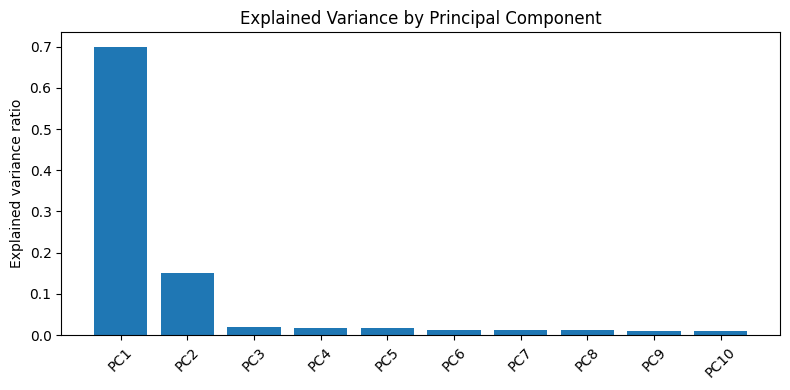

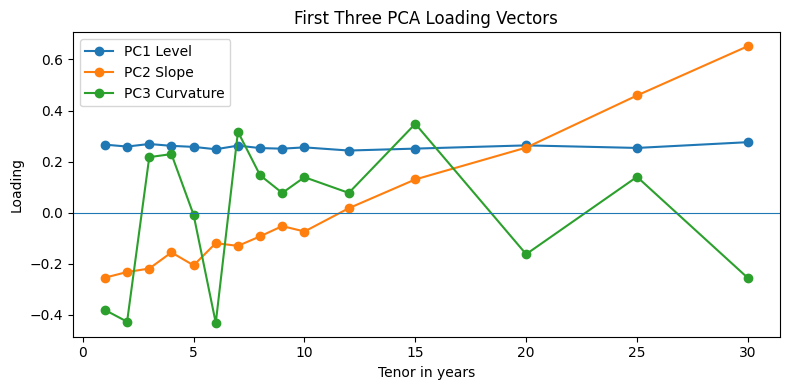

In [8]:
# Cell 8 — Plot explained variance and PC loading shapes
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(explained['PC'].head(10), explained['Explained Variance'].head(10))
ax.set_title('Explained Variance by Principal Component')
ax.set_ylabel('Explained variance ratio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for idx in pc_loadings.index:
    ax.plot(TENOR_YEARS, pc_loadings.loc[idx].values, marker='o', label=idx)
ax.axhline(0, linewidth=0.8)
ax.set_title('First Three PCA Loading Vectors')
ax.set_xlabel('Tenor in years')
ax.set_ylabel('Loading')
ax.legend()
plt.tight_layout()
plt.show()


### PCA interpretation

- **PC1** is the level factor because its loading vector is broad and same-signed across the curve.
- **PC2** is the slope factor because short and long maturities load with opposite signs.
- **PC3** is the curvature factor because the belly of the curve loads differently from the wings.

This is why a butterfly, which is designed to reduce level and slope exposure, naturally concentrates its residual exposure in the curvature direction.


## 3. Load aggregate risk and hedging instruments

The repository files are used directly when present. If they are missing, exact fallback copies are created from the values shown in the public repo so the notebook remains runnable.


In [9]:
# Cell 9 — Load risk_agg.csv and hedging_instruments.csv, with fallback data if needed
risk_path = repo_root / 'risk_agg.csv'
hedge_path = repo_root / 'hedging_instruments.csv'

if risk_path.exists():
    risk_agg = pd.read_csv(risk_path)
else:
    risk_agg = pd.DataFrame([
        ['AGG_RISK', 2.9829718673, -1.8575544755, 0.0132791298, 0.0711852838,
         13.9751286464, -5.4585911886, -0.0257717119, -7.003277095,
         0.0436237494, 12.7837665143, -15.2568588949, -21.1387297939,
         -17.4444822831, 0.0, 0.0]
    ], columns=['Instrument'] + TENORS)

if hedge_path.exists():
    hedging = pd.read_csv(hedge_path)
else:
    hedging = pd.DataFrame([
        ['1Y1Y', 0.9903830167, -1.9057802671, -0.0404369051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ['1Y5Y', 0.9864149870, 0.0065780132, 0.0005733754, 0.0017144790, 0.0491289758, -5.4685109719, -0.0354355475, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ['5Y5Y', 0.0029699945, 0.0059819157, 0.0091487000, 0.0123361695, 4.6269518330, -0.0163515307, -0.0193596051, -0.0223091163, -0.0255841305, -8.5011966113, 0.0, 0.0, 0.0, 0.0, 0.0],
        ['10Y10Y', 0.0036991705, 0.0074648768, 0.0113986259, 0.0153658701, 0.0196424993, 0.0239804073, 0.0285432572, 0.0328849633, 0.0377357338, 8.4999828061, -0.0937678030, -0.1983093418, -14.3351205715, 0.0, 0.0]
    ], columns=['Instrument'] + TENORS)

risk_agg = clean_risk_table(risk_agg, 'Instrument')
hedging = clean_risk_table(hedging, 'Instrument')

print('Aggregate risk:')
display(risk_agg)
print('Hedging instruments:')
display(hedging)


Aggregate risk:


,Instrument,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,AGG_RISK,2.982972,-1.857554,0.013279,0.071185,13.975129,-5.458591,-0.025772,-7.003277,0.043624,12.783767,-15.256859,-21.138730,-17.444482,0.000000,0.000000


Hedging instruments:


,Instrument,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,1Y1Y,0.990383,-1.905780,-0.040437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1Y5Y,0.986415,0.006578,0.000573,0.001714,0.049129,-5.468511,-0.035436,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,5Y5Y,0.002970,0.005982,0.009149,0.012336,4.626952,-0.016352,-0.019360,-0.022309,-0.025584,-8.501197,0.000000,0.000000,0.000000,0.000000,0.000000
3,10Y10Y,0.003699,0.007465,0.011399,0.015366,0.019642,0.023980,0.028543,0.032885,0.037736,8.499983,-0.093768,-0.198309,-14.335121,0.000000,0.000000


In [10]:
# Cell 10 — Prepare vectors/matrices for hedging
risk_vector = risk_agg.loc[0, TENORS].to_numpy(dtype=float)       # length n_tenors
instrument_names = hedging['Instrument'].astype(str).tolist()
hedge_matrix = hedging[TENORS].to_numpy(dtype=float)              # n_instruments x n_tenors

print('Risk vector shape:', risk_vector.shape)
print('Hedge matrix shape:', hedge_matrix.shape)
print('Instruments:', instrument_names)


Risk vector shape: (15,)
Hedge matrix shape: (4, 15)
Instruments: ['1Y1Y', '1Y5Y', '5Y5Y', '10Y10Y']


## 4. Direct least-squares hedge

The direct hedge solves:

\[
\min_x \lVert r + xH \rVert_2^2,
\]

where \(r\) is the aggregate DV01 vector and \(H\) is the hedging-instrument DV01 matrix.


In [11]:
# Cell 11 — Direct least-squares hedge
# Solve H.T x = -r, where x is instrument weight vector.
weights_direct, residuals_direct_lstsq, rank_direct, s_direct = np.linalg.lstsq(
    hedge_matrix.T,
    -risk_vector,
    rcond=None
)

hedged_direct = risk_vector + weights_direct @ hedge_matrix

direct_summary = pd.DataFrame({
    'Instrument': instrument_names,
    'Direct LS Weight': weights_direct
})

print('Direct LS hedge weights:')
display(direct_summary)

print('Direct residual RMSE:', rmse(hedged_direct))
print('Direct residual L2 norm:', float(np.linalg.norm(hedged_direct)))


Direct LS hedge weights:


,Instrument,Direct LS Weight
0,1Y1Y,-1.193592
1,1Y5Y,-1.045629
2,5Y5Y,-0.674989
3,10Y10Y,-1.487148


Direct residual RMSE: 7.65478832990502
Direct residual L2 norm: 29.64686772046503


## 5. PCA / eigenspace hedge

The PCA hedge focuses on the dominant curve-risk factors instead of trying to match every tenor bucket exactly. Using the first \(k\) principal components, solve:

\[
\min_x \lVert P_k(r+xH)^T \rVert_2^2,
\]

where \(P_k\) contains the first \(k\) PCA loading vectors. Equivalently, it hedges the aggregate risk in the reduced eigenspace spanned by the largest-variance curve factors.

Here, \(k=3\), corresponding to level, slope, and curvature.


In [12]:
# Cell 12 — PCA/eigenspace hedge using first 3 PCs
K = 3
P = pca['components'][:K]                 # K x n_tenors

# Orienting PC signs is irrelevant for least squares. Use original PCA components for math.
risk_pc = P @ risk_vector                  # K
hedge_pc = hedge_matrix @ P.T              # n_instruments x K

# Solve hedge_pc.T x = -risk_pc.
weights_pca, residuals_pca_lstsq, rank_pca, s_pca = np.linalg.lstsq(
    hedge_pc.T,
    -risk_pc,
    rcond=None
)

hedged_pca = risk_vector + weights_pca @ hedge_matrix
hedged_pca_pc = P @ hedged_pca

pca_summary = pd.DataFrame({
    'Instrument': instrument_names,
    'PCA/Eigenspace Weight': weights_pca
})

print('PCA/eigenspace hedge weights:')
display(pca_summary)

print('Residual exposure in first 3 PC space:', hedged_pca_pc)
print('PCA-space residual RMSE:', rmse(hedged_pca_pc))
print('Full-tenor residual RMSE:', rmse(hedged_pca))
print('Full-tenor residual L2 norm:', float(np.linalg.norm(hedged_pca)))


PCA/eigenspace hedge weights:


,Instrument,PCA/Eigenspace Weight
0,1Y1Y,0.139221
1,1Y5Y,0.345469
2,5Y5Y,-7.004655
3,10Y10Y,-1.821598


Residual exposure in first 3 PC space: [ 1.19904087e-14  6.21724894e-15 -1.02140518e-14]
PCA-space residual RMSE: 9.776688925667997e-15
Full-tenor residual RMSE: 17.173455280887158
Full-tenor residual L2 norm: 66.51250629971378


In [13]:
# Cell 13 — Compare unhedged, direct LS, and PCA/eigenspace hedge residuals
comparison = pd.DataFrame({
    'Tenor': TENORS,
    'Original Aggregate DV01': risk_vector,
    'Residual after Direct LS': hedged_direct,
    'Residual after PCA Hedge': hedged_pca,
})
comparison


,Tenor,Original Aggregate DV01,Residual after Direct LS,Residual after PCA Hedge
0,1Y,2.982972,0.761929,3.434088
1,2Y,-1.857554,0.395152,-2.176106
2,3Y,0.013279,0.037818,-0.077000
3,4Y,0.071185,0.038214,-0.042623
4,5Y,13.975129,10.771407,-18.453879
5,6Y,-5.458591,0.234816,-7.276940
6,7Y,-0.025772,-0.018100,0.045599
7,8Y,-7.003277,-7.037124,-6.906913
8,9Y,0.043624,0.004774,0.154092
9,10Y,12.783767,5.881243,56.848160


In [14]:
# Cell 14 — Summary metrics
metric_table = pd.DataFrame([
    {
        'Method': 'Unhedged',
        'Full-Tenor L2 Norm': np.linalg.norm(risk_vector),
        'Full-Tenor RMSE': rmse(risk_vector),
        'PC1-3 Exposure L2 Norm': np.linalg.norm(P @ risk_vector),
        'PC1-3 Exposure RMSE': rmse(P @ risk_vector),
        'Weight L2 Norm': 0.0,
    },
    {
        'Method': 'Direct Least Squares',
        'Full-Tenor L2 Norm': np.linalg.norm(hedged_direct),
        'Full-Tenor RMSE': rmse(hedged_direct),
        'PC1-3 Exposure L2 Norm': np.linalg.norm(P @ hedged_direct),
        'PC1-3 Exposure RMSE': rmse(P @ hedged_direct),
        'Weight L2 Norm': np.linalg.norm(weights_direct),
    },
    {
        'Method': 'PCA / Eigenspace',
        'Full-Tenor L2 Norm': np.linalg.norm(hedged_pca),
        'Full-Tenor RMSE': rmse(hedged_pca),
        'PC1-3 Exposure L2 Norm': np.linalg.norm(P @ hedged_pca),
        'PC1-3 Exposure RMSE': rmse(P @ hedged_pca),
        'Weight L2 Norm': np.linalg.norm(weights_pca),
    },
])
metric_table


,Method,Full-Tenor L2 Norm,Full-Tenor RMSE,PC1-3 Exposure L2 Norm,PC1-3 Exposure RMSE,Weight L2 Norm
0,Unhedged,37.866279,9.777031,14.377440,8.300819,0.000000
1,Direct Least Squares,29.646868,7.654788,11.910466,6.876511,2.277108
2,PCA / Eigenspace,66.512506,17.173455,0.000000,0.000000,7.247216


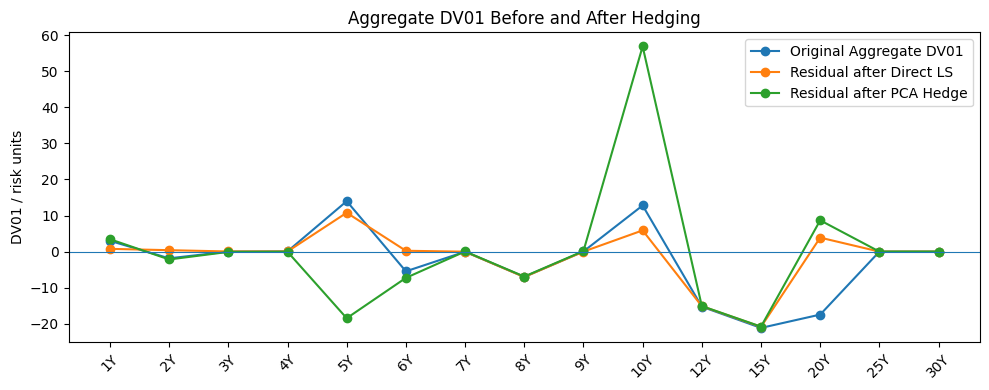

In [15]:
# Cell 15 — Plot hedge residuals by tenor
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(TENORS))
ax.plot(x, risk_vector, marker='o', label='Original Aggregate DV01')
ax.plot(x, hedged_direct, marker='o', label='Residual after Direct LS')
ax.plot(x, hedged_pca, marker='o', label='Residual after PCA Hedge')
ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TENORS, rotation=45)
ax.set_title('Aggregate DV01 Before and After Hedging')
ax.set_ylabel('DV01 / risk units')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Why PCA/eigenspace hedging is preferred

Direct least squares minimizes bucket-by-bucket residual DV01 over all tenors. That can look attractive mechanically, but it treats every tenor bucket as equally important and can overfit small/noisy local key-rate exposures. In fixed-income curves, most realized daily variation is usually driven by a few systematic factors: level, slope, and curvature.

The PCA hedge instead minimizes residual exposure in the dominant eigenspace:

\[
\min_x \lVert P_k(r+xH)^T \rVert_2^2.
\]

This is preferred because:

1. **Economic interpretation:** the first three PCs correspond to level, slope, and curvature, which are the main market risk factors for yield-curve moves.
2. **Noise reduction:** lower-variance PCs often represent idiosyncratic bucket noise rather than stable hedgeable risk.
3. **Stability:** hedges based on dominant eigenvectors are less sensitive to small changes in the input risk vector.
4. **Risk relevance:** hedging the high-variance eigenspace reduces exposure to the curve moves that are most likely to drive realized P&L.

Therefore, the PCA/eigenspace hedge may leave more full-bucket residual risk than direct least squares, but it better targets the systematic market-risk directions that matter most.


In [16]:
# Cell 16 — Export useful result tables
output_dir = repo_root / 'assignment5_outputs'
output_dir.mkdir(exist_ok=True)

explained.to_csv(output_dir / 'pca_explained_variance.csv', index=False)
pc_loadings.to_csv(output_dir / 'pca_first_three_loadings.csv')
direct_summary.merge(pca_summary, on='Instrument').to_csv(output_dir / 'hedge_weights_comparison.csv', index=False)
comparison.to_csv(output_dir / 'hedge_residuals_by_tenor.csv', index=False)
metric_table.to_csv(output_dir / 'hedge_metric_comparison.csv', index=False)

print('Saved outputs to:', output_dir)
for p in sorted(output_dir.glob('*.csv')):
    print(' -', p.name)


Saved outputs to: /mnt/data/assignment5_outputs
 - hedge_metric_comparison.csv
 - hedge_residuals_by_tenor.csv
 - hedge_weights_comparison.csv
 - pca_explained_variance.csv
 - pca_first_three_loadings.csv
